In [1]:
# Per subject, per feature, per trial event: what % of pref-selective units
# (`pref_99th_window_filter_drift_units`) are also present in the choice-selective
# units (`choice_99th_window_filter_drift_units`)?
#
# These pickles come from scripts/multi_session_analysis/20250606_generate_significant_units.py:
# per (subject, event), one row per (feat, PseudoUnitID) that was significant in ANY window,
# after unioning over StimOnset/FeedbackOnsetLong-window ANOVAs and dropping drifting/bad-region units.

import numpy as np
import pandas as pd

In [2]:
SUBJECTS = ["BL", "SA"]
EVENTS = ["StimOnset", "FeedbackOnsetLong"]
UNITS_PATH = "/data/patrick_res/firing_rates/{sub}/{event}_{level}_units.pickle"


def load_units(sub, event, level):
    df = pd.read_pickle(UNITS_PATH.format(sub=sub, event=event, level=level))
    return df[["feat", "PseudoUnitID"]].drop_duplicates()


pref_units = {(sub, event): load_units(sub, event, "pref_99th_window_filter_drift")
              for sub in SUBJECTS for event in EVENTS}
choice_units = {(sub, event): load_units(sub, event, "choice_99th_window_filter_drift")
                for sub in SUBJECTS for event in EVENTS}

In [3]:
def compute_overlap(sub, event):
    pref = pref_units[(sub, event)]
    choice = choice_units[(sub, event)]
    rows = []
    for feat, pref_feat in pref.groupby("feat"):
        pref_ids = set(pref_feat.PseudoUnitID)
        choice_ids = set(choice.loc[choice.feat == feat, "PseudoUnitID"])
        n_pref = len(pref_ids)
        n_both = len(pref_ids & choice_ids)
        rows.append({
            "subject": sub,
            "trial_event": event,
            "feat": feat,
            "n_pref": n_pref,
            "n_pref_also_choice": n_both,
            "pct_pref_also_choice": 100 * n_both / n_pref if n_pref else np.nan,
        })
    return pd.DataFrame(rows)


overlap = pd.concat(
    [compute_overlap(sub, event) for sub in SUBJECTS for event in EVENTS],
    ignore_index=True,
)
overlap

,subject,trial_event,feat,n_pref,n_pref_also_choice,pct_pref_also_choice
0,BL,StimOnset,CIRCLE,7,1,14.285714
1,BL,StimOnset,CYAN,18,5,27.777778
2,BL,StimOnset,ESCHER,53,26,49.056604
3,BL,StimOnset,GREEN,6,3,50.000000
4,BL,StimOnset,MAGENTA,20,11,55.000000
5,BL,StimOnset,POLKADOT,17,10,58.823529
6,BL,StimOnset,RIPPLE,24,7,29.166667
7,BL,StimOnset,SQUARE,7,6,85.714286
8,BL,StimOnset,STAR,24,17,70.833333
9,BL,StimOnset,SWIRL,25,13,52.000000


**Note:** StimOnset and FeedbackOnsetLong give identical numbers per subject above. This is
expected, not a bug: `generate_significant_units.py` unions significance over both events
*before* saving and writes the same resulting dataframe under both event filenames (see the
caveat in `20260731_pref_choice_selectivity_overlap.ipynb`). These `*_99th_window_filter_drift`
pickles carry no per-event or per-window information — a unit counts as pref/choice-selective if
it was significant in *either* event, in *any* window. For an actual per-window, per-event
breakdown, use `io_utils.read_anova_good_units` directly as in that notebook.

In [4]:
# pivot: rows = feat, cols = (subject, trial_event), values = % pref units also choice-selective
pivot = overlap.pivot_table(index="feat", columns=["subject", "trial_event"], values="pct_pref_also_choice")
pivot

subject                    BL                           SA           
trial_event FeedbackOnsetLong  StimOnset FeedbackOnsetLong  StimOnset
feat                                                                 
CIRCLE              14.285714  14.285714         55.978261  55.978261
CYAN                27.777778  27.777778         41.401274  41.401274
ESCHER              49.056604  49.056604         53.211009  53.211009
GREEN               50.000000  50.000000         35.416667  35.416667
MAGENTA             55.000000  55.000000         46.783626  46.783626
POLKADOT            58.823529  58.823529         51.879699  51.879699
RIPPLE              29.166667  29.166667         55.357143  55.357143
SQUARE              85.714286  85.714286         66.666667  66.666667
STAR                70.833333  70.833333         61.702128  61.702128
SWIRL               52.000000  52.000000         46.902655  46.902655
TRIANGLE            66.666667  66.666667         65.263158  65.263158
YELLOW              41.176471  41.176471         47.959184  47.959184

In [5]:
# summary: mean % across features, per (subject, event), plus pooled count-based %
summary = overlap.groupby(["subject", "trial_event"]).agg(
    mean_pct_across_feats=("pct_pref_also_choice", "mean"),
    total_n_pref=("n_pref", "sum"),
    total_n_pref_also_choice=("n_pref_also_choice", "sum"),
).reset_index()
summary["pooled_pct"] = 100 * summary["total_n_pref_also_choice"] / summary["total_n_pref"]
summary

,subject,trial_event,mean_pct_across_feats,total_n_pref,total_n_pref_also_choice,pooled_pct
0,BL,FeedbackOnsetLong,50.041754,242,122,50.413223
1,BL,StimOnset,50.041754,242,122,50.413223
2,SA,FeedbackOnsetLong,52.376789,1682,871,51.783591
3,SA,StimOnset,52.376789,1682,871,51.783591


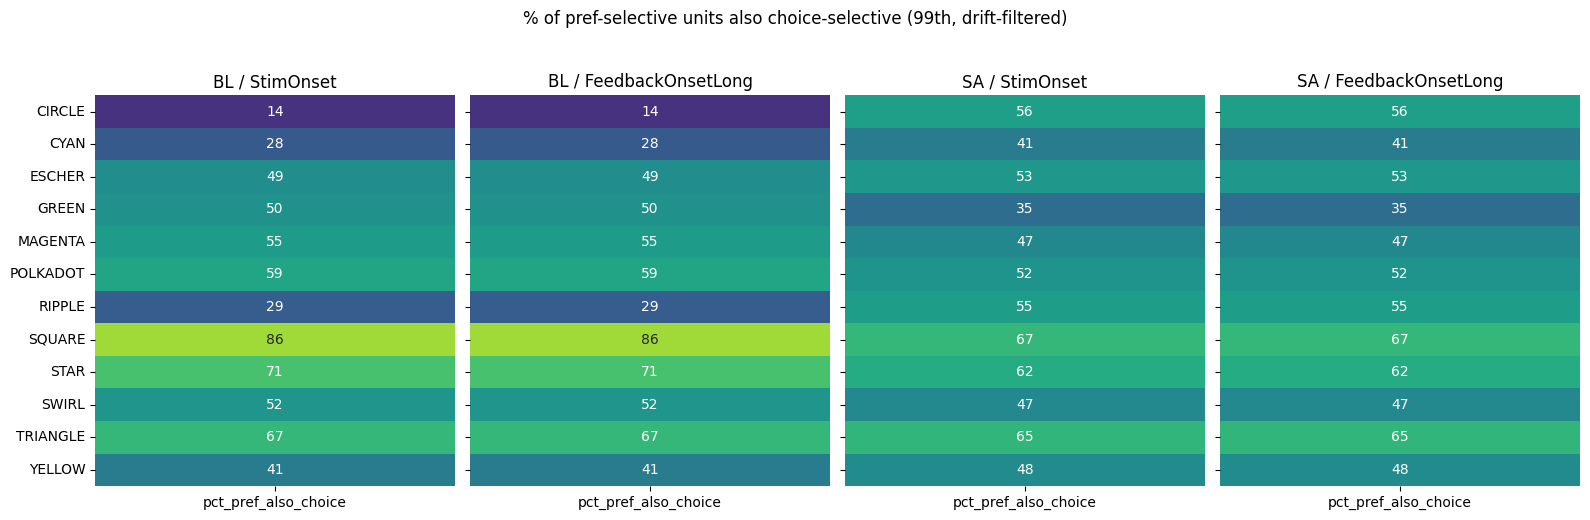

In [6]:
import seaborn as sns
from matplotlib import pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
for ax, (sub, event) in zip(axs, [(s, e) for s in SUBJECTS for e in EVENTS]):
    d = overlap[(overlap.subject == sub) & (overlap.trial_event == event)].set_index("feat")
    sns.heatmap(d[["pct_pref_also_choice"]], annot=True, fmt=".0f", vmin=0, vmax=100,
                cmap="viridis", cbar=False, ax=ax)
    ax.set_title(f"{sub} / {event}")
    ax.set_ylabel("")
fig.suptitle("% of pref-selective units also choice-selective (99th, drift-filtered)", y=1.03)
fig.tight_layout()
plt.show()